In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn import preprocessing

In [2]:
df_initial = pd.read_csv('data_clean.csv', index_col=0)

In [3]:
df_initial

,product_name,cat,description,image
0,Elegance Polyester Multicolor Abstract Eyelet ...,Home Furnishing,Key Features of Elegance Polyester Multicolor ...,55b85ea15a1536d46b7190ad6fff8ce7.jpg
1,Sathiyas Cotton Bath Towel,Baby Care,Specifications of Sathiyas Cotton Bath Towel (...,7b72c92c2f6c40268628ec5f14c6d590.jpg
2,Eurospa Cotton Terry Face Towel Set,Baby Care,Key Features of Eurospa Cotton Terry Face Towe...,64d5d4a258243731dc7bbb1eef49ad74.jpg
3,SANTOSH ROYAL FASHION Cotton Printed King size...,Home Furnishing,Key Features of SANTOSH ROYAL FASHION Cotton P...,d4684dcdc759dd9cdf41504698d737d8.jpg
4,Jaipur Print Cotton Floral King sized Double B...,Home Furnishing,Key Features of Jaipur Print Cotton Floral Kin...,6325b6870c54cd47be6ebfbffa620ec7.jpg
...,...,...,...,...
1045,Oren Empower Extra Large Self Adhesive Sticker,Baby Care,Oren Empower Extra Large Self Adhesive Sticker...,958f54f4c46b53c8a0a9b8167d9140bc.jpg
1046,Wallmantra Large Vinyl Sticker Sticker,Baby Care,Wallmantra Large Vinyl Sticker Sticker (Pack o...,fd6cbcc22efb6b761bd564c28928483c.jpg
1047,Uberlyfe Extra Large Pigmented Polyvinyl Films...,Baby Care,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,5912e037d12774bb73a2048f35a00009.jpg
1048,Wallmantra Medium Vinyl Sticker Sticker,Baby Care,Buy Wallmantra Medium Vinyl Sticker Sticker fo...,c3edc504d1b4f0ba6224fa53a43a7ad6.jpg


In [4]:
from PIL import Image

In [5]:
img = ['image', 'cat']

In [6]:
df_img = df_initial[img]

In [7]:
le = preprocessing.LabelEncoder()
df_img["label"] = le.fit_transform(df_img["cat"])

C:\Users\LN6428\AppData\Local\Temp\ipykernel_20428\301370474.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_img["label"] = le.fit_transform(df_img["cat"])


In [8]:
list_labels = ['Home Furnishing', 'Baby Care', 'Watches', 'Home Decor & Festive Needs', 'Kitchen & Dining', 'Beauty and Personal Care', 'Computers']

In [9]:
from os import listdir
path = "C:/Users/LN6428/Documents/P6/Images/"

In [10]:
#pip install opencv-python

In [11]:
#pip install opencv-contrib-python

import cv2

sift = cv2.xfeatures2d.SIFT_create()
image = cv2.imread(path+list_photos[3],0) # convert in gray
image = cv2.equalizeHist(image)   # equalize image histogram
kp, des = sift.detectAndCompute(image, None)
img=cv2.drawKeypoints(image,kp,image)
plt.imshow(img)
plt.show()
print("Descripteurs : ", des.shape)
print()
print(des)

In [12]:
# identification of key points and associated descriptors
import time, cv2
sift_keypoints = []
temps1=time.time()
sift = cv2.xfeatures2d.SIFT_create(300)

for image_num in range(df_img.shape[0]) :
    if image_num%100 == 0 : print(image_num)
    image = cv2.imread(path+df_img['image'][image_num],0) # convert in gray
    # blur
    smooth = cv2.GaussianBlur(image, (95,95), 0)
    # divide gray by morphology image
    image = cv2.divide(image, smooth, scale=255)
    #image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY) 
    res = cv2.equalizeHist(image)   # equalize image histogram
    kp, des = sift.detectAndCompute(res, None)
    sift_keypoints.append(des)

sift_keypoints_by_img = np.asarray(sift_keypoints)
sift_keypoints_all    = np.concatenate(sift_keypoints_by_img, axis=0)

print()
print("Nombre de descripteurs : ", sift_keypoints_all.shape)

duration1=time.time()-temps1
print("temps de traitement SIFT descriptor : ", "%15.2f" % duration1, "secondes")

0
100
200
300
400
500
600
700
800
900
1000

Nombre de descripteurs :  (315276, 128)
temps de traitement SIFT descriptor :           236.98 secondes


C:\Users\LN6428\AppData\Local\Temp\ipykernel_20428\984683641.py:19: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sift_keypoints_by_img = np.asarray(sift_keypoints)


## Création des clusters de descripteurs
* Utilisation de MiniBatchKMeans pour obtenir des temps de traitement raisonnables

In [13]:
from sklearn import cluster, metrics

# Determination number of clusters
temps1=time.time()

k = int(round(np.sqrt(len(sift_keypoints_all)),0))
print("Nombre de clusters estimés : ", k)
print("Création de",k, "clusters de descripteurs ...")

# Clustering
kmeans = cluster.MiniBatchKMeans(n_clusters=k, init_size=3*k, random_state=0)
kmeans.fit(sift_keypoints_all)

duration1=time.time()-temps1
print("temps de traitement kmeans : ", "%15.2f" % duration1, "secondes")

Nombre de clusters estimés :  561
Création de 561 clusters de descripteurs ...


C:\Users\LN6428\Anaconda3\envs\new_env2\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\LN6428\Anaconda3\envs\new_env2\lib\site-packages\sklearn\cluster\_kmeans.py:1902: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


temps de traitement kmeans :             4.14 secondes


## Création des features des images
* Pour chaque image : 
   - prédiction des numéros de cluster de chaque descripteur
   - création d'un histogramme = comptage pour chaque numéro de cluster du nombre de descripteurs de l'image
   
   Features d'une image = Histogramme d'une image = Comptage pour une image du nombre de descripteurs par cluster

In [14]:
# Creation of histograms (features)
temps1=time.time()

def build_histogram(kmeans, des, image_num):
    res = kmeans.predict(des)
    hist = np.zeros(len(kmeans.cluster_centers_))
    nb_des=len(des)
    if nb_des==0 : print("problème histogramme image  : ", image_num)
    for i in res:
        hist[i] += 1.0/nb_des
    return hist


# Creation of a matrix of histograms
hist_vectors=[]

for i, image_desc in enumerate(sift_keypoints_by_img) :
    if i%100 == 0 : print(i)  
    hist = build_histogram(kmeans, image_desc, i) #calculates the histogram
    hist_vectors.append(hist) #histogram is the feature vector

im_features = np.asarray(hist_vectors)

duration1=time.time()-temps1
print("temps de création histogrammes : ", "%15.2f" % duration1, "secondes")

0
100
200
300
400
500
600
700
800
900
1000
temps de création histogrammes :            44.12 secondes


### Réduction de dimension PCA
* La réduction PCA permet de créer des features décorrélées entre elles, et de diminuer leur dimension, tout en gardant un niveau de variance expliquée élevé (99%)
* L'impact est une meilleure séparation des données via le T-SNE et une réduction du temps de traitement du T-SNE

In [15]:
from sklearn import manifold, decomposition

print("Dimensions dataset avant réduction PCA : ", im_features.shape)
pca = decomposition.PCA(n_components=0.99)
feat_pca= pca.fit_transform(im_features)
print("Dimensions dataset après réduction PCA : ", feat_pca.shape)

Dimensions dataset avant réduction PCA :  (1050, 561)
Dimensions dataset après réduction PCA :  (1050, 439)


### Réduction de dimension T-SNE
* Réduction de dimension en 2 composantes T-SNE pour affichage en 2D des images

In [16]:
from sklearn import manifold, decomposition

tsne = manifold.TSNE(n_components=2, perplexity=30, 
                     n_iter=2000, init='random', random_state=6)
X_tsne = tsne.fit_transform(feat_pca)

df_tsne = pd.DataFrame(X_tsne[:,0:2], columns=['tsne1', 'tsne2'])
df_tsne["class"] = df_img["cat"]
print(df_tsne.shape)

(1050, 3)


## Analyse visuelle : affichage T-SNE selon catégories d'images

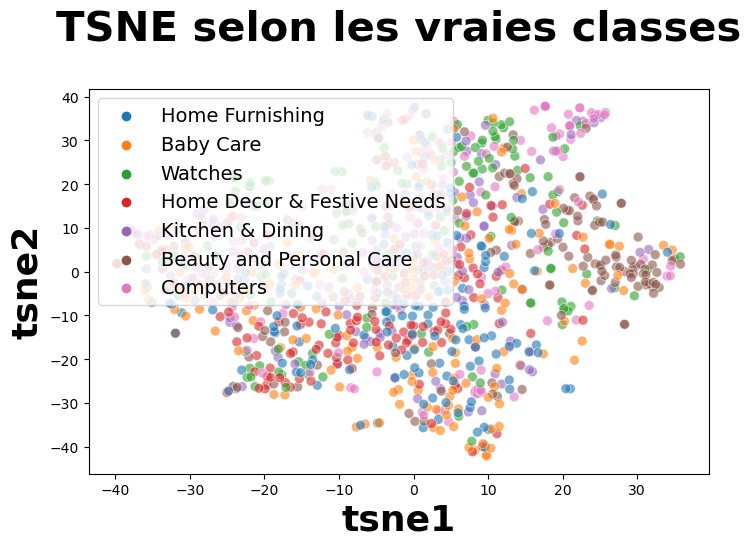

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="tsne1", y="tsne2", hue="class", data=df_tsne, legend="brief",
    palette=sns.color_palette('tab10', n_colors=7), s=50, alpha=0.6)

plt.title('TSNE selon les vraies classes', fontsize = 30, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 26, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 26, fontweight = 'bold')
plt.legend(prop={'size': 14}) 

plt.show()

## Analyse mesures : similarité entre catégories et clusters
###  Création de clusters à partir du T-SNE

In [18]:
from sklearn import cluster, metrics

cls = cluster.KMeans(n_clusters=7, random_state=6)
cls.fit(X_tsne)

df_tsne["cluster"] = cls.labels_
print(df_tsne.shape)

C:\Users\LN6428\Anaconda3\envs\new_env2\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\LN6428\Anaconda3\envs\new_env2\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


(1050, 4)


###  Affichage des images selon clusters et calcul ARI de similarité catégories images / clusters

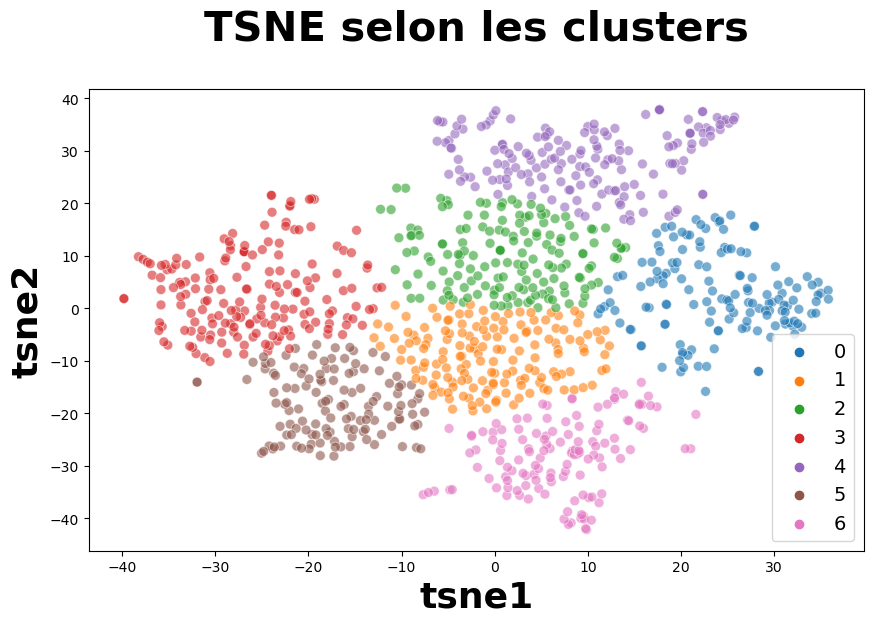

ARI :  0.06571455742041499


In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="cluster",
    palette=sns.color_palette('tab10', n_colors=7), s=50, alpha=0.6,
    data=df_tsne,
    legend="brief")

plt.title('TSNE selon les clusters', fontsize = 30, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 26, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 26, fontweight = 'bold')
plt.legend(prop={'size': 14}) 

plt.show()

labels = df_img["label"]
print("ARI : ", metrics.adjusted_rand_score(labels, cls.labels_))

### Analyse par classes
* La matrice de confusion doit être transformée pour avoir en colonne le même ordre des catégories supposées qu'en ligne

In [26]:
df_tsne.groupby("cluster").count()["class"]

cluster
0    144
1    156
2    155
3    177
4    163
5    126
6    129
Name: class, dtype: int64

In [32]:
conf_mat = metrics.confusion_matrix(labels, cls.labels_)
print(conf_mat)

[[19 18 15 31  9 18 40]
 [74  9 15 11 18 14  9]
 [11  7 18 33 53 10 18]
 [ 7 49 21 17  8 39  9]
 [ 7 37 22 19 12 18 35]
 [ 6 25 37 39 19 10 14]
 [20 11 27 27 44 17  4]]


In [42]:
def conf_mat_transform(y_true,y_pred) :
    conf_mat = metrics.confusion_matrix(y_true,y_pred)
    
    #corresp = np.argmax(conf_mat, axis=0)
    corresp = [1, 4, 6, 5, 2, 3, 0]
    print ("Correspondance des clusters : ", corresp)
    # y_pred_transform = np.apply_along_axis(correspond_fct, 1, y_pred)
    labels = pd.Series(y_true, name="y_true").to_frame()
    labels['y_pred'] = y_pred
    labels['y_pred_transform'] = labels['y_pred'].apply(lambda x : corresp[x]) 
    
    return labels['y_pred_transform']

cls_labels_transform = conf_mat_transform(labels, cls.labels_)
conf_mat = metrics.confusion_matrix(labels, cls_labels_transform)
print(conf_mat)
print()
print(metrics.classification_report(labels, cls_labels_transform))

Correspondance des clusters :  [1, 4, 6, 5, 2, 3, 0]
[[40 19  9 18 18 31 15]
 [ 9 74 18 14  9 11 15]
 [18 11 53 10  7 33 18]
 [ 9  7  8 39 49 17 21]
 [35  7 12 18 37 19 22]
 [14  6 19 10 25 39 37]
 [ 4 20 44 17 11 27 27]]

              precision    recall  f1-score   support

           0       0.31      0.27      0.29       150
           1       0.51      0.49      0.50       150
           2       0.33      0.35      0.34       150
           3       0.31      0.26      0.28       150
           4       0.24      0.25      0.24       150
           5       0.22      0.26      0.24       150
           6       0.17      0.18      0.18       150

    accuracy                           0.29      1050
   macro avg       0.30      0.29      0.30      1050
weighted avg       0.30      0.29      0.30      1050



<AxesSubplot: >

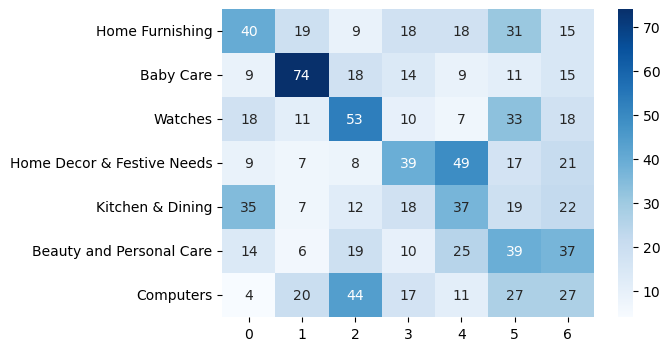

In [43]:
df_cm = pd.DataFrame(conf_mat, index = [label for label in list_labels],
                  columns = [i for i in "0123456"])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")

## Pre-Trained Model VGG16 as Feature Extractor Preprocessor

In [38]:
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.applications.vgg16 import preprocess_input
from keras.applications.vgg16 import decode_predictions
from keras.applications.vgg16 import VGG16
from keras.models import Model
from pickle import dump

In [44]:
# load an image from file
image = load_img(path+df_initial['image'][image_num], target_size=(224, 224))
# convert the image pixels to a numpy array
image = img_to_array(image)
# reshape data for the model
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
# prepare the image for the VGG model
image = preprocess_input(image)
# load model
model = VGG16()
# remove the output layer
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
# get extracted features
features = model.predict(image)
print(features.shape)

1/1 [==============================] - 1s 913ms/step
(1, 4096)


In [47]:
# Extraction des features sur l'ensemble des images
import time
extracted_features = []
temps1=time.time()

for image_num in range(len(df_img['image'])) :
    if image_num%100 == 0 : print(image_num)
    # Prétraitement des images
    image = load_img(path+df_img['image'][image_num], target_size=(224, 224))
    image = img_to_array(image)    
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    
    # get extracted features
    features = model.predict(image)
    features.flatten()
    extracted_features.append(features)
    

duration1=time.time()-temps1
print("temps de traitement : ", "%15.2f" % duration1, "secondes")

0
1/1 [==============================] - 0s 248ms/step
100
1/1 [==============================] - 0s 238ms/step


1/1 [==============================] - 0s 241ms/step
200
1/1 [==============================] - 0s 274ms/step
300
1/1 [==============================] - 0s 228ms/step


1/1 [==============================] - 0s 259ms/step
400
1/1 [==============================] - 0s 232ms/step


1/1 [==============================] - 0s 237ms/step
500
1/1 [==============================] - 0s 233ms/step
600
1/1 [==============================] - 0s 242ms/step


1/1 [==============================] - 0s 242ms/step


C:\Users\LN6428\Anaconda3\envs\new_env2\lib\site-packages\PIL\Image.py:2918: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


1/1 [==============================] - 0s 224ms/step
700
1/1 [==============================] - 0s 226ms/step
800
1/1 [==============================] - 0s 272ms/step


1/1 [==============================] - 0s 240ms/step
900
1/1 [==============================] - 0s 241ms/step


1/1 [==============================] - 0s 229ms/step
1000
1/1 [==============================] - 0s 229ms/step
temps de traitement :           450.83 secondes


In [51]:
features = np.asarray(extracted_features).reshape(1050, 4096)

In [52]:
from sklearn import manifold, decomposition

print("Dimensions dataset avant réduction PCA : ", features.shape)
pca = decomposition.PCA(n_components=0.99)
feat_pca= pca.fit_transform(features)
print("Dimensions dataset après réduction PCA : ", feat_pca.shape)

Dimensions dataset avant réduction PCA :  (1050, 4096)
Dimensions dataset après réduction PCA :  (1050, 803)


In [53]:
from sklearn import manifold, decomposition

tsne = manifold.TSNE(n_components=2, perplexity=30, 
                     n_iter=2000, init='random', random_state=6)
X_tsne = tsne.fit_transform(feat_pca)

df_tsne = pd.DataFrame(X_tsne[:,0:2], columns=['tsne1', 'tsne2'])
df_tsne["class"] = df_img["cat"]
print(df_tsne.shape)

(1050, 3)


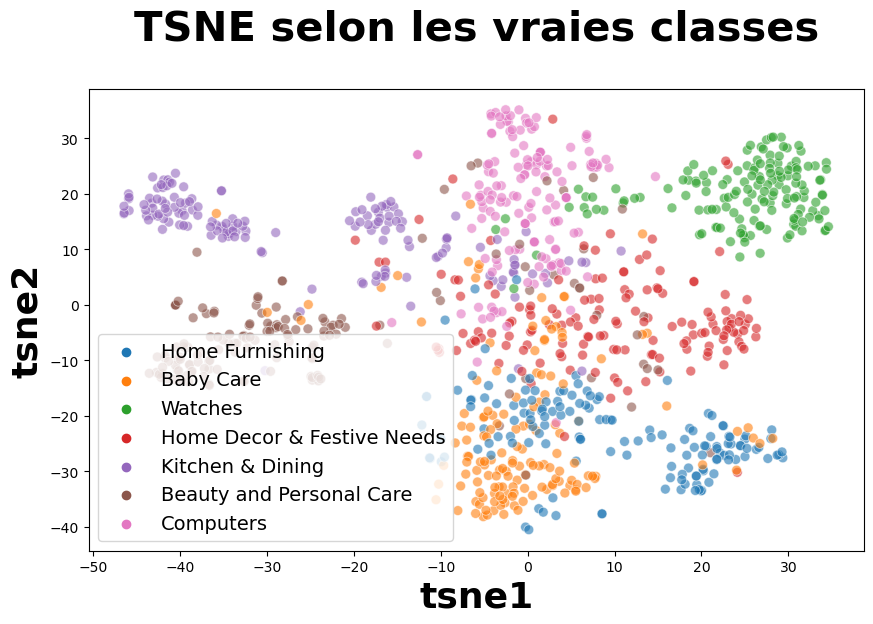

In [54]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="tsne1", y="tsne2", hue="class", data=df_tsne, legend="brief",
    palette=sns.color_palette('tab10', n_colors=7), s=50, alpha=0.6)

plt.title('TSNE selon les vraies classes', fontsize = 30, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 26, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 26, fontweight = 'bold')
plt.legend(prop={'size': 14}) 

plt.show()

In [55]:
from sklearn import cluster, metrics

cls = cluster.KMeans(n_clusters=7, random_state=6)
cls.fit(X_tsne)

df_tsne["cluster"] = cls.labels_
print(df_tsne.shape)

C:\Users\LN6428\Anaconda3\envs\new_env2\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\LN6428\Anaconda3\envs\new_env2\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


(1050, 4)


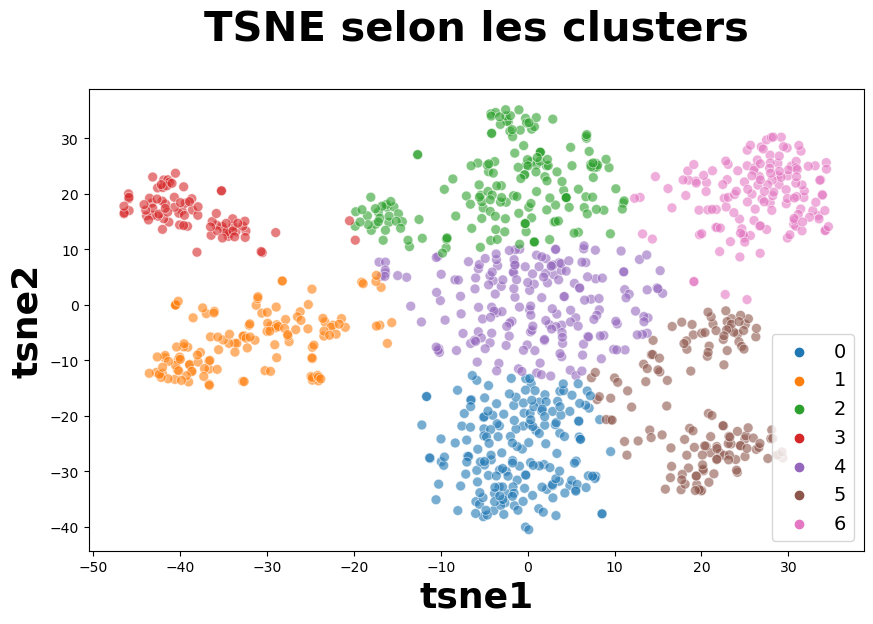

ARI :  0.45668559488413096


In [56]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="cluster",
    palette=sns.color_palette('tab10', n_colors=7), s=50, alpha=0.6,
    data=df_tsne,
    legend="brief")

plt.title('TSNE selon les clusters', fontsize = 30, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 26, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 26, fontweight = 'bold')
plt.legend(prop={'size': 14}) 

plt.show()

labels = df_img["cat"]
print("ARI : ", metrics.adjusted_rand_score(labels, cls.labels_))

In [62]:
labels = df_img['label']

In [63]:
## Matrice de confusion
conf_mat = metrics.confusion_matrix(labels, cls.labels_)
print(conf_mat)

[[109   4   1   1  26   8   1]
 [  4 117   9   1  13   6   0]
 [  1   1 113   0  34   0   1]
 [  2   1   5   1  82  51   8]
 [ 72   0   0   0   5  73   0]
 [  0   7  37  79  27   0   0]
 [  0   0  13   0   2   0 135]]


In [67]:
def conf_mat_transform(y_true,y_pred) :
    conf_mat = metrics.confusion_matrix(y_true,y_pred)
    
    corresp = np.argmax(conf_mat, axis=0)
    #corresp = [1, 4, 6, 5, 2, 3, 0]
    print ("Correspondance des clusters : ", corresp)
    # y_pred_transform = np.apply_along_axis(correspond_fct, 1, y_pred)
    labels = pd.Series(y_true, name="y_true").to_frame()
    labels['y_pred'] = y_pred
    labels['y_pred_transform'] = labels['y_pred'].apply(lambda x : corresp[x]) 
    
    return labels['y_pred_transform']

cls_labels_transform = conf_mat_transform(labels, cls.labels_)
conf_mat = metrics.confusion_matrix(labels, cls_labels_transform)
print(conf_mat)
print()
print(metrics.classification_report(labels, cls_labels_transform))

Correspondance des clusters :  [0 1 2 5 3 4 6]
[[109   4   1  26   8   1   1]
 [  4 117   9  13   6   1   0]
 [  1   1 113  34   0   0   1]
 [  2   1   5  82  51   1   8]
 [ 72   0   0   5  73   0   0]
 [  0   7  37  27   0  79   0]
 [  0   0  13   2   0   0 135]]

              precision    recall  f1-score   support

           0       0.58      0.73      0.64       150
           1       0.90      0.78      0.84       150
           2       0.63      0.75      0.69       150
           3       0.43      0.55      0.48       150
           4       0.53      0.49      0.51       150
           5       0.96      0.53      0.68       150
           6       0.93      0.90      0.92       150

    accuracy                           0.67      1050
   macro avg       0.71      0.67      0.68      1050
weighted avg       0.71      0.67      0.68      1050



<AxesSubplot: >

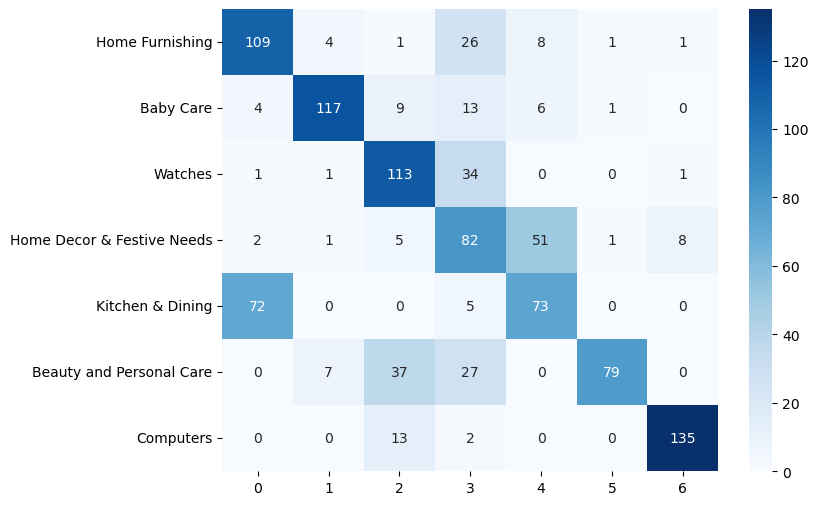

In [72]:
df_cm = pd.DataFrame(conf_mat, index = [label for label in list_labels],
                  columns = [i for i in "0123456"])
plt.figure(figsize = (8,6))
sns.heatmap(df_cm, annot=True, cmap="Blues", fmt='.3g')